# Visualizing Individual Myelin Content Maps

This notebook generates visualizations for the first 10 individual myelin content maps in the study.  
For each subject, it plots the middle axial, coronal, and sagittal slices using the `actc` colormap, keeping the exact format used for the group averages.  
To ensure comparison across subjects, a **single, common color scale range** (2nd to 98th percentile of all subjects combined) is used for all plots.

In [1]:
# Standard Library:
import os
import re
from pathlib import Path

# Numerical Computing & Data Handling:
import numpy as np
import pandas as pd

# Neuroimaging:
!pip install nibabel
import nibabel as nib

# Visualization:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Utilities:
from tqdm import tqdm

In [2]:
# Define metadata path:
metadata_path = "../../../eda/OASIS3_metadata_clean.csv"

# Load metadata file:
metadata = pd.read_csv(metadata_path)

# Keep only relevant columns:
metadata = metadata[["Subject_ID", "DEMENTED", "NORMCOG"]]

# Create lookup by Subject_ID:
metadata = metadata.set_index("Subject_ID")

# Define the directory containing myelin maps:
myelin_dir = Path("../myelin_maps")

# Sort the files by the subject ID:
files = sorted(myelin_dir.glob("sub-*_sT1T2.nii.gz"), key=lambda f: int(re.search(r"sub-OAS(\d+)", f.name).group(1)))

print(f"Total myelin map files found: {len(files)}")

Total myelin map files found: 1177


In [3]:
# Define helper function to plot middle slices of a 3D brain volume:
def plot_middle_slices(vol, cmap, title, cbar_title, background=False, vmin=None, vmax=None, save_info=None):

    # Unpack volume dimensions:
    x, y, z = vol.shape

    # Define brain mask file path:
    mask_path = "../../../templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"
    
    # Load brain mask volume:
    mask_img = nib.load(mask_path)
    mask = mask_img.get_fdata()

    # If enabled, compute robust display range using only brain voxels:
    if vmin is None or vmax is None:
        # Obtain non-zero values:
        brain_vals = vol[mask > 0]

        # Compute 2nd percentile:
        p2 = np.percentile(brain_vals, 2)
        vmin = p2

        # Proceed only if background condition is enabled:
        if background:
            # Compute 95th percentile:
            p95 = np.percentile(brain_vals, 95)
            vmin = p95

        # Compute 99.5th percentile:        
        p99_5 = np.percentile(brain_vals, 99.5)
        vmax = p99_5

    # Extract middle axial, coronal and sagittal slices:
    axial = vol[:, :, z // 2]
    coronal = vol[:, y // 2, :]
    sagittal = vol[x // 2, :, :]
    
    # Extract corresponding mask slices:
    axial_mask = mask[:, :, z // 2]
    coronal_mask = mask[:, y // 2, :]
    sagittal_mask = mask[x // 2, :, :]

    # Mask zero values in axial, coronal and sagittal slices:
    axial = np.ma.masked_where(axial_mask == 0, axial)
    coronal = np.ma.masked_where(coronal_mask == 0, coronal)
    sagittal = np.ma.masked_where(sagittal_mask == 0, sagittal)

    # Create figure with 3 side-by-side subplots:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Display axial slice:
    axes[0].imshow(axial.T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
    axes[0].set_title('Axial', y=0.95, fontsize=16)
    axes[0].axis('off')

    # Display coronal slice:
    axes[1].imshow(coronal.T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
    axes[1].set_title('Coronal', y=0.95, fontsize=16)
    axes[1].axis('off')

    # Display sagittal slice:
    im = axes[2].imshow(sagittal.T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
    axes[2].set_title('Sagittal', y=1, fontsize=16)
    axes[2].axis('off')

    # Set general figure title:
    fig.suptitle(title, fontsize=20, y=1.02)

    # Reduce spacing between subplots:
    plt.subplots_adjust(wspace=-0.1)

    # Create dedicated colorbar axis and place it:
    cax = fig.add_axes([0.92, 0.15, 0.025, 0.7])

    # Define custom colorbar ticks:
    ticks = np.linspace(vmin, vmax, 8)
    cbar = fig.colorbar(im, cax=cax, ticks=ticks)
    
    # Build tick labels:
    tick_labels = [f"{t:.2f}" for t in ticks]
    
    # Modify first and last ticks:
    tick_labels[0] = rf"$\mathbf{{V_{{min}}}}$ = {ticks[0]:.2f}"
    tick_labels[-1] = rf"$\mathbf{{V_{{max}}}}$ = {ticks[-1]:.2f}"

    # Apply changes:
    cbar.set_ticklabels(tick_labels)

    # Set colorbar label:
    cbar.set_label(cbar_title, fontsize=16, fontweight='bold', labelpad=8)

    # Define colorbar ticks' style:
    cbar.ax.tick_params(labelsize=10, width=1.5, length=6)
    cbar.outline.set_linewidth(1.5)

    # Define output folder:
    output_folder = "Figures/Myelin_Maps"

    # Make sure output folder exists:
    os.makedirs(output_folder, exist_ok=True)

    # Save figure:
    fig.savefig(f"{output_folder}/Individual_Myelin_Map_{save_info}.svg", dpi=300, bbox_inches="tight")

    # Render the figure:
    plt.show()

In [4]:
# Load brain colors actc colormap:
actc_colors = np.loadtxt("../../../fsl_colormaps/brain_colours/actc.cmap")

# Create a custom Matplotlib colormap object:
actc_cmap = ListedColormap(actc_colors, name="actc")

# Define brain mask file path:
mask_path = "../../../templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"
    
# Load brain mask volume:
mask_img = nib.load(mask_path)
mask = mask_img.get_fdata()

Loading first 10 myelin maps to calculate a common color scale...
Common color scale range (2nd to 98th percentile): vmin = -0.7320, vmax = 0.7629

Plotting individual myelin maps with the same colorscale:


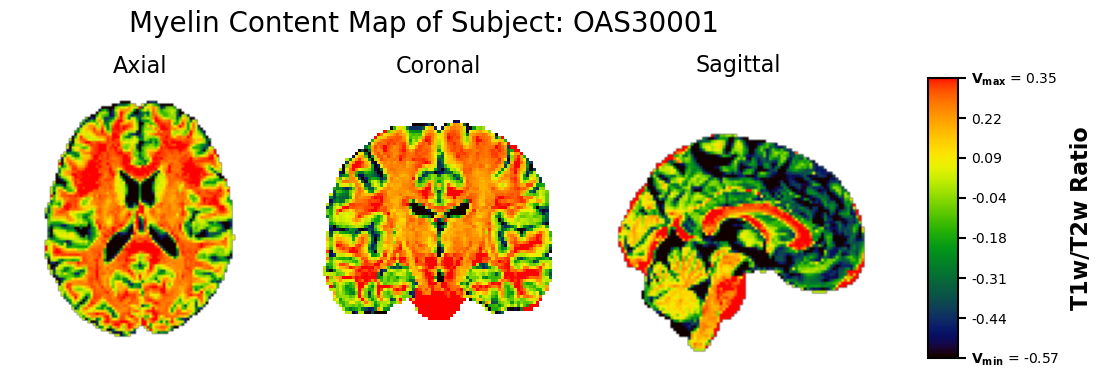

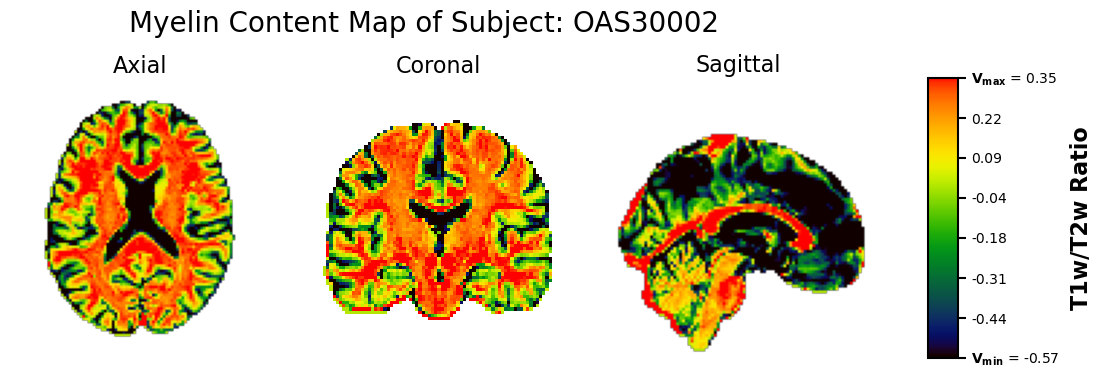

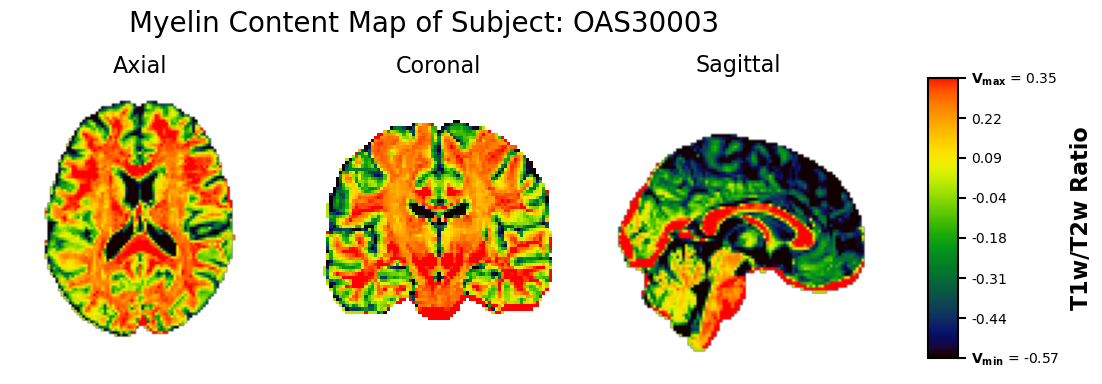

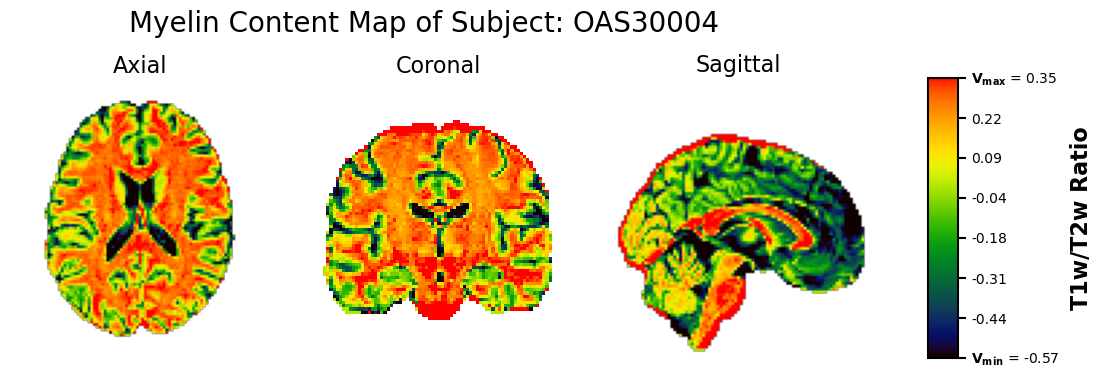

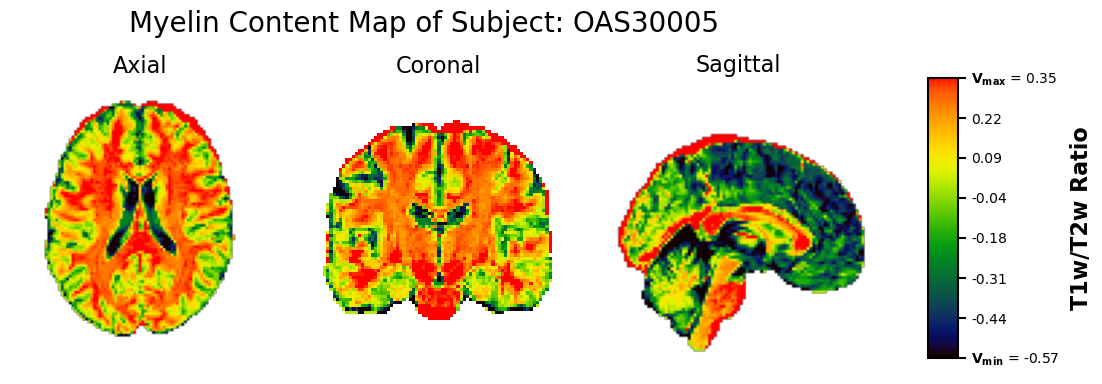

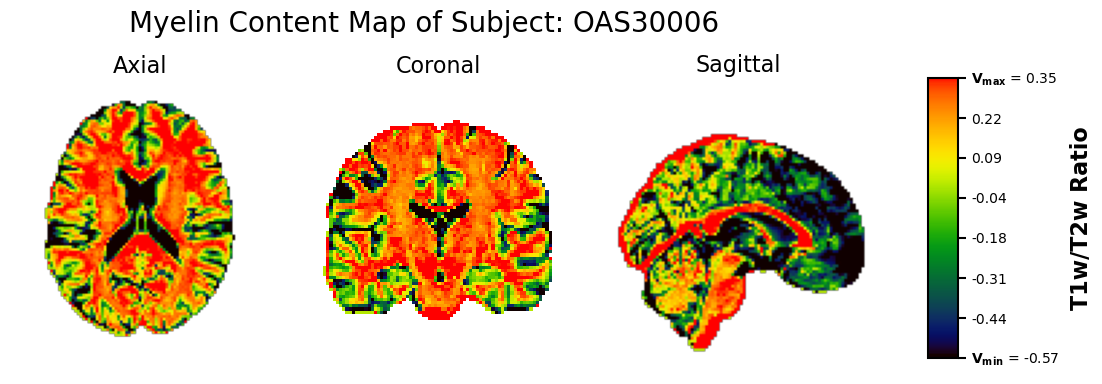

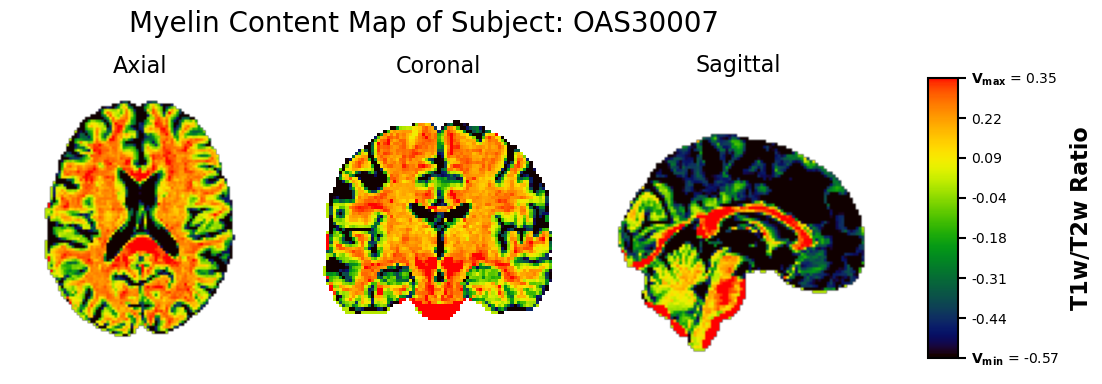

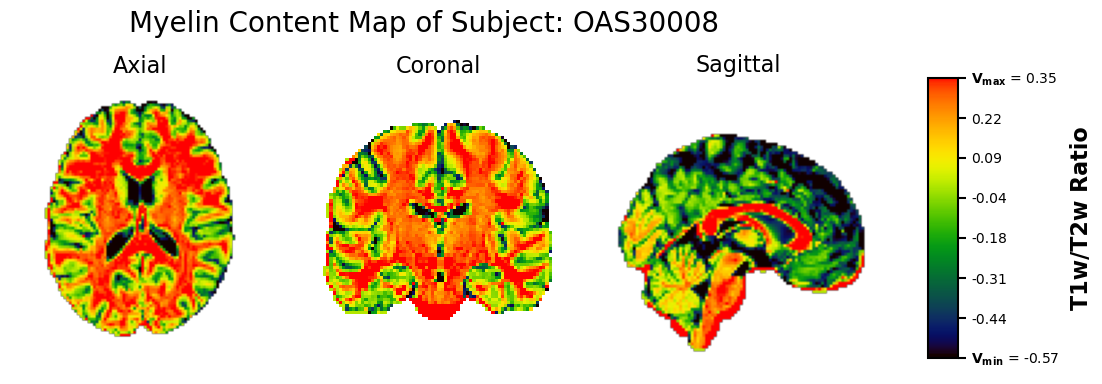

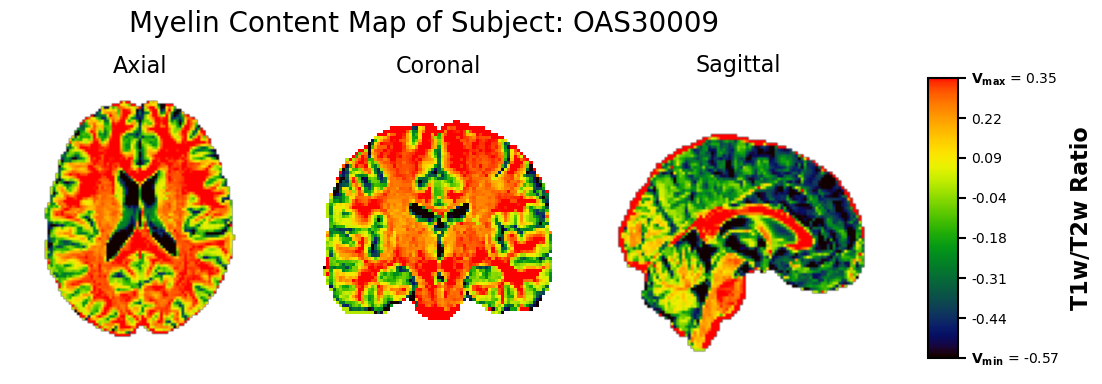

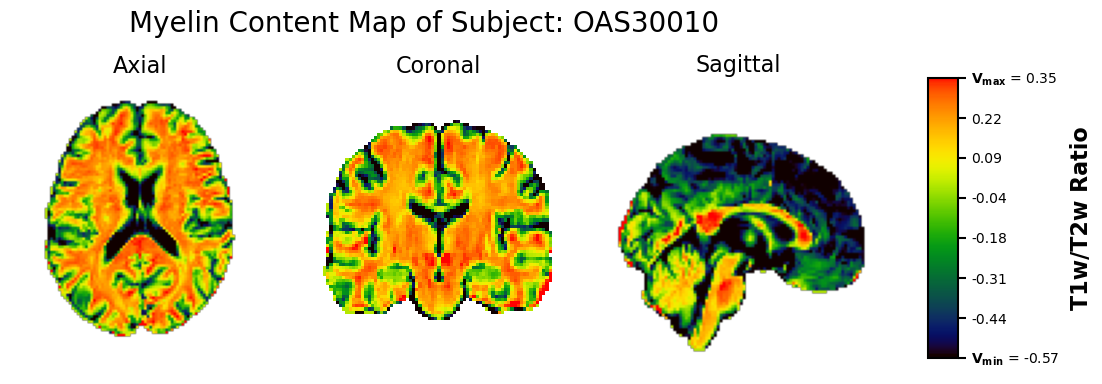

In [6]:
# Get the first 10 myelin map files:
first_10_files = files[:10]

print(f"Loading first {len(first_10_files)} myelin maps to calculate a common color scale...")

subject_maps = []
all_brain_vals = []

for f in first_10_files:
    # Extract subject ID:
    subject_id = re.search(r"sub-(OAS\d+)", f.name).group(1)
    
    # Load the myelin map:
    img = nib.load(f)
    data = img.get_fdata()
    
    # Store for plotting later:
    subject_maps.append((subject_id, data))
    
    # Accumulate brain voxels for global percentile calculation:
    all_brain_vals.append(data[mask > 0])

# Compute a common robust display range (2nd and 98th percentiles across all 10 subjects combined):
all_brain_vals = np.concatenate(all_brain_vals)
vmin = np.percentile(all_brain_vals, 2)
vmax = np.percentile(all_brain_vals, 98)

print(f"Common color scale range (2nd to 98th percentile): vmin = {vmin:.4f}, vmax = {vmax:.4f}")
print("\nPlotting individual myelin maps with the same colorscale:")

for subject_id, data in subject_maps:
    title = f"Myelin Content Map of Subject: {subject_id}"
    
    # Call the helper function to plot the individual map using the common vmin and vmax:
    plot_middle_slices(
        data, 
        actc_cmap, 
        title=title, 
        cbar_title="T1w/T2w Ratio", 
        vmin=-0.57, 
        vmax=0.35, 
        save_info=subject_id
    )